[   2.79486242 1720.59559678   23.20282043   32.21962392]
[-4.43833414e-09  2.33333333e+03 -3.00000000e+04 -6.66666667e+03]
[ 1.74622983e-10  2.33333333e+03 -3.00000000e+04 -6.66666667e+03]


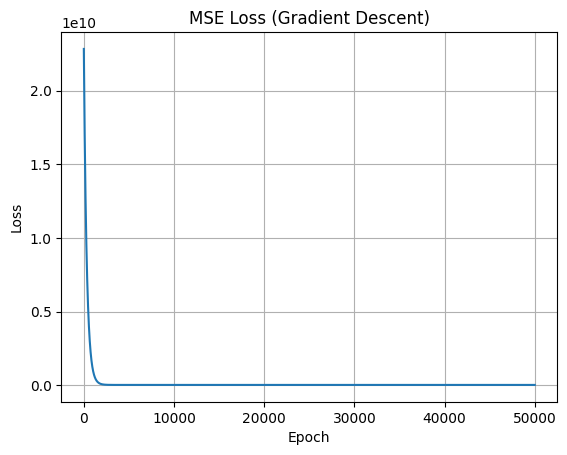

[   2.79486242 1720.59559678   23.20282043   32.21962392]
[-4.43833414e-09  2.33333333e+03 -3.00000000e+04 -6.66666667e+03]
[ 1.74622983e-10  2.33333333e+03 -3.00000000e+04 -6.66666667e+03]


In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def hypothesis(X, w):
    return X @ w

def mse_loss(X, y, w):
    m = len(y)
    return (1/(2*m)) * np.sum((X @ w - y)**2)

def gradient_step(X, y, w, lr):
    m = len(y)
    grad = (1/m) * (X.T @ (X @ w - y))
    return w - lr * grad

def train_gd(X, y, lr=0.0000001, epochs=50000):
    w = np.zeros(X.shape[1])
    history = []
    for _ in range(epochs):
        w = gradient_step(X, y, w, lr)
        history.append(mse_loss(X, y, w))
    return w, history

X = np.array([
    [50, 1, 1],
    [70, 1, 2],
    [120, 2, 3],
    [200, 3, 4]
], dtype=float)

y = np.array([80000, 120000, 200000, 350000], dtype=float)

X_b = np.hstack([np.ones((X.shape[0], 1)), X])

w_gd, history = train_gd(X_b, y)
print(w_gd)

def normal_equation(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

w_ne = normal_equation(X_b, y)
print(w_ne)

model = LinearRegression()
model.fit(X, y)
w_sklearn = np.hstack([model.intercept_, model.coef_])
print(w_sklearn)

plt.plot(history)
plt.title("MSE Loss (Gradient Descent)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

print(w_gd)
print(w_ne)
print(w_sklearn)